In [1]:
# TO DO also: 
# data loader for final number of partitions: force it to be what specified instead of always half??;

# (consider using run_worker_sweep for simplicity??)
# DEBUG NEW KMEANS (check matrices stuff)?  ---> try with "old" kmeans??

# clean up code (image saving, etc)?
# re-run final, clean code?

# K-means|| distribuito su Dask — Analisi

Notebook di orchestrazione: avvia il cluster, carica il dataset, esegue i test (singola run o benchmark su più combinazioni) e salva i risultati in `./results`.

Moduli usati:
- `kmeans_parallel.py` — algoritmo k-means|| distribuito
- `launch_cluster.py` — avvio/spegnimento del cluster Dask via SSH
- `data_loader.py` — caricamento del dataset
- `benchmark.py` — esecuzione dei test e salvataggio risultati

#### Useful: to kill existing Dask processes (from bash):
```bash
for ip in 10.67.22.194 10.67.22.254 10.67.22.34 10.67.22.145 10.67.22.121 10.67.22.192 10.67.22.18 10.67.22.187 10.67.22.48; do
    echo "Killing on $ip..."
    ssh -o StrictHostKeyChecking=no ubuntu@"$ip" "pkill -9 -f dask-scheduler; pkill -9 -f dask-worker; pkill -9 -f dask_ssh" 
done
```

## 1. Import

In [1]:
import numpy as np
import pandas as pd
from src.kmeans_parallel import kmeans_parallel
from src.launch_cluster import launch_cluster, shutdown_cluster
from src.data_loader import load_dataset
from src.benchmark import run_single_test, run_benchmark, calculate_inertia, combinations_fn

import time

## 2. Parametri configurabili

Modifica qui i valori per cambiare numero di worker, `k`, `l` (oversampling factor) e `r` (numero di round dell'inizializzazione parallela).

In [2]:
# --- Cluster ---
N_WORKERS = 8      # tra 1 e 8 (nodi disponibili in launch_cluster.py)
NUM_PARTITIONS = 8 * N_WORKERS   # regola empirica: >= n_threads_per_worker * n_workers

In [3]:
# --- Algoritmo k-means|| ---
#K = 500                # numero di cluster finali
#L = 250                # oversampling factor (assoluto). In alternativa: L = round(L_OVER_K * K)
#R = 10                  # numero di round dell'inizializzazione parallela
#MAX_ITER_FIT = 100      # iterazioni massime della fase di Lloyd's (fit)

SEED = 42

In [4]:
# --- Dataset ---
DATASET_URL_10PC = "https://ndownloader.figshare.com/files/5976042"
# link used by sklearn function fetch_kddcup99 (original link gives 403 error)
#***for 10% dataset***

DATASET_URL_FULL="https://ndownloader.figshare.com/files/5976045"
#***FULL DATASET***

RAW_GZ_PATH_10PC   = "/home/ubuntu/Project/libero_development/data/kddcup_data.gz" # compressed (.gz) dataset file
PARQUET_PATH_10PC = '/tmp/kddcup_data.parquet' # single Parquet file (ie a compressed format file but partition-able, unlike .gz) on master

RAW_GZ_PATH_FULL = "/home/ubuntu/backup/libero_development/data/kddcup_data_full.gz"
PARQUET_PATH_FULL = '/tmp/kddcup_data_full.parquet'

# column names of KDD dataset, from source code of the above sklearn function;
# "protocol_type","service","flag" are non-numeric so they will be dropped later,
# as will be "label" and the constant column 'num_outbound_cmds' 
# (10% dataset might have more constant columns such as 'is_host_login')
COL_NAMES = [
    "duration","protocol_type","service","flag","src_bytes",
    "dst_bytes","land","wrong_fragment","urgent","hot",
    "num_failed_logins","logged_in","num_compromised","root_shell",
    "su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate",
    "dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate",
    "dst_host_srv_rerror_rate","label"
]

## 3. Start cluster

In [10]:
# DO NOT RUN if already existing!
cluster, client = launch_cluster(N_WORKERS)

Inizializzazione del cluster SSH con 8 worker...
Worker selezionati: ['10.67.22.254', '10.67.22.34', '10.67.22.145', '10.67.22.121', '10.67.22.192', '10.67.22.18', '10.67.22.187', '10.67.22.48']


2026-08-28 13:32:27,240 - distributed.deploy.ssh - INFO - 2026-08-28 13:32:27,240 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-08-28 13:32:27,268 - distributed.deploy.ssh - INFO - 2026-08-28 13:32:27,268 - distributed.scheduler - INFO - State start
2026-08-28 13:32:27,273 - distributed.deploy.ssh - INFO - 2026-08-28 13:32:27,272 - distributed.scheduler - INFO -   Scheduler at:   tcp://10.67.22.194:8786
2026-08-28 13:32:29,302 - distributed.deploy.ssh - INFO - 2026-08-28 13:32:29,298 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.48:39001'
2026-08-28 13:32:29,305 - distributed.deploy.ssh - INFO - 2026-08-28 13:32:29,300 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.145:45879'
2026-08-28 13:32:29,310 - distributed.deploy.ssh - INFO - 2026-08-28 13:32:29,300 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.254

Cluster avviato e connessione stabilita con successo!



#### Connect to cluster IF INSTEAD already exsiting:

In [7]:
from dask.distributed import Client

SCHEDULER_ADDRESS = "tcp://10.67.22.194:8786"

try:
    client = Client(SCHEDULER_ADDRESS, timeout="10s")
    print("Connected to cluster successfully!")
    print(f"Dask Dashboard link: {client.dashboard_link}")

except Exception as e:
    print(f"Connection error: {e}")

Connected to cluster successfully!
Dask Dashboard link: http://10.67.22.194:8787/status


In [8]:
client.scheduler_info()

{'type': 'Scheduler',
 'id': 'Scheduler-68e8624f-880c-40cf-a998-b9473d689023',
 'address': 'tcp://10.67.22.194:8786',
 'services': {'dashboard': 8787},
 'started': 1787909509.394774,
 'n_workers': 8,
 'total_threads': 64,
 'total_memory': 66574651392,
 'workers': {'tcp://10.67.22.121:44271': {'type': 'Worker',
   'id': 'tcp://10.67.22.121:44271',
   'host': '10.67.22.121',
   'resources': {},
   'local_directory': '/tmp/dask-scratch-space/worker-xslv8wve',
   'name': 'tcp://10.67.22.121:44271',
   'nthreads': 8,
   'memory_limit': 8321835008,
   'last_seen': 1787909512.4262962,
   'services': {'dashboard': 37623},
   'metrics': {'task_counts': {},
    'bandwidth': {'total': 100000000, 'workers': {}, 'types': {}},
    'digests_total_since_heartbeat': {},
    'managed_bytes': 0,
    'spilled_bytes': {'memory': 0, 'disk': 0},
    'transfer': {'incoming_bytes': 0,
     'incoming_count': 0,
     'incoming_count_total': 0,
     'outgoing_bytes': 0,
     'outgoing_count': 0,
     'outgoing_count_total': 0},
    'event_loop_interval': 0.02,
    'cpu': 0.0,
    'memory': 58355712,
    'time': 1787909512.3869648,
    'host_net_io': {'read_bps': 0.0, 'write_bps': 0.0},
    'host_disk_io': {'read_bps': 0.0, 'write_bps': 0.0},
    'num_fds': 17},
   'status': 'running',
   'nanny': 'tcp://10.67.22.121:40693'},
  'tcp://10.67.22.145:38065': {'type': 'Worker',
   'id': 'tcp://10.67.22.145:38065',
   'host': '10.67.22.145',
   'resources': {},
   'local_directory': '/tmp/dask-scratch-space/worker-_h7gu9rm',
   'name': 'tcp://10.67.22.145:38065',
   'nthreads': 8,
   'memory_limit': 8321835008,
   'last_seen': 1787909512.3732023,
   'services': {'dashboard': 34487},
   'metrics': {'task_counts': {},
    'bandwidth': {'total': 100000000, 'workers': {}, 'types': {}},
    'digests_total_since_heartbeat': {},
    'managed_bytes': 0,
    'spilled_bytes': {'memory': 0, 'disk': 0},
    'transfer': {'incoming_bytes': 0,
     'incoming_count': 0,
     'incoming_count_total': 0,
     'outgoing_bytes': 0,
     'outgoing_count': 0,
     'outgoing_count_total': 0},
    'event_loop_interval': 0.02,
    'cpu': 0.0,
    'memory': 58290176,
    'time': 1787909512.3350348,
    'host_net_io': {'read_bps': 0.0, 'write_bps': 0.0},
    'host_disk_io': {'read_bps': 0.0, 'write_bps': 0.0},
    'num_fds': 17},
   'status': 'running',
   'nanny': 'tcp://10.67.22.145:40025'},
  'tcp://10.67.22.187:34547': {'type': 'Worker',
   'id': 'tcp://10.67.22.187:34547',
   'host': '10.67.22.187',
   'resources': {},
   'local_directory': '/tmp/dask-scratch-space/worker-wy4q6ylc',
   'name': 'tcp://10.67.22.187:34547',
   'nthreads': 8,
   'memory_limit': 8321822720,
   'last_seen': 1787909512.4528909,
   'services': {'dashboard': 45525},
   'metrics': {'task_counts': {},
    'bandwidth': {'total': 100000000, 'workers': {}, 'types': {}},
    'digests_total_since_heartbeat': {},
    'managed_bytes': 0,
    'spilled_bytes': {'memory': 0, 'disk': 0},
    'transfer': {'incoming_bytes': 0,
     'incoming_count': 0,
     'incoming_count_total': 0,
     'outgoing_bytes': 0,
     'outgoing_count': 0,
     'outgoing_count_total': 0},
    'event_loop_interval': 0.02,
    'cpu': 0.0,
    'memory': 59215872,
    'time': 1787909512.4190347,
    'host_net_io': {'read_bps': 121914.52092952843, 'write_bps': 0.0},
    'host_disk_io': {'read_bps': 0.0, 'write_bps': 0.0},
    'num_fds': 17},
   'status': 'running',
   'nanny': 'tcp://10.67.22.187:34013'},
  'tcp://10.67.22.18:46085': {'type': 'Worker',
   'id': 'tcp://10.67.22.18:46085',
   'host': '10.67.22.18',
   'resources': {},
   'local_directory': '/tmp/dask-scratch-space/worker-qiqzy6p2',
   'name': 'tcp://10.67.22.18:46085',
   'nthreads': 8,
   'memory_limit': 8321835008,
   'last_seen': 1787909513.1975627,
   'services': {'dashboard': 42873},
   'metrics': {'task_counts': {},
    'bandwidth': {'total': 100000000, 'workers': {}, 'types': {}},
    'digests_total_since_heartbeat': {'latency': 0.03647351264953613,
     'tick-duration': 0.9820

## 4. Load dataset

In [9]:
#10 percent:

start=time.time()
X_bag_10_percent, (mean_ar, std_ar)=load_dataset(n_partitions=NUM_PARTITIONS,
                   client=client,
                   dataset_url=DATASET_URL_10PC,
                   raw_gz_path=RAW_GZ_PATH_10PC,
                   parquet_path=PARQUET_PATH_10PC,
                   parquet_path_workers=PARQUET_PATH_10PC,
                   col_names=COL_NAMES,
                   force_download=False)
end=time.time()
elapsed=end-start
print(f"Time elapsed: {elapsed:.2f} s")

Using cached dataset: /home/ubuntu/Project/libero_development/data/kddcup_data.gz
Converting .gz -> Parquet chunk sizes...
Parquet file created (compressed with snappy).
Number of partitions before preprocessing: 64
Constant columns: ['num_outbound_cmds', 'is_host_login']
Computing global mean and std (first pass over data)...
Distributed bag created with 32 partitions.
Number of samples: 494021
Time elapsed: 12.98 s


In [10]:
# if want to go back to original coordinates later:
#print(mean_ar, '\n\n\n') 
#print(std_ar)

In [ ]:
# full:

start=time.time()
X_bag_full, (mean_ar, std_ar)=load_dataset(n_partitions=NUM_PARTITIONS,
                   client=client,
                   dataset_url=DATASET_URL_FULL,#DATASET_URL_10PC,
                   raw_gz_path=RAW_GZ_PATH_FULL,#RAW_GZ_PATH,
                   parquet_path=PARQUET_PATH_FULL,#PARQUET_PATH,
                   parquet_path_workers=PARQUET_PATH_FULL,#PARQUET_PATH,
                   col_names=COL_NAMES,
                   force_download=True)
end=time.time()
elapsed=end-start
print(f"Time elapsed: {elapsed:.2f} s")

#### Check that loaded correctly

In [ ]:
# this was done earlier, for full dataset:

In [ ]:
# global variable used in data_loader.py 
print(f"Number of initial features (should be 42): {len(COL_NAMES)}")

In [ ]:
lengths = X_bag_full.map(len).frequencies().compute() # length of every row- its unnormalized PMF
print("Feature count distribution (should be 37 for full dataset, see below):", lengths)
# Should show one unique length, 37 (see below)

In [ ]:
n_points = X_bag_full.count().compute()
n_features = X_bag_full.map(len).take(1)[0] # since all rows have same length
print(f"Points: {n_points}, Features: {n_features}\n(Full dataset should contain 4898431 samples with 37 (=42 -1 label -3 non numeric -1 constant feature) numerical, non-constant features)")

In [ ]:
has_nan = X_bag_full.map(lambda x: np.isnan(x).any()).any().compute()
has_inf = X_bag_full.map(lambda x: np.isinf(x).any()).any().compute()
print(f"Has NaN: {has_nan}, Has Inf: {has_inf}\n(Both must be False)")

In [ ]:
total = X_bag_full.reduction(
    lambda part: np.sum(np.vstack(list(part)), axis=0),
    lambda parts: np.sum(list(parts), axis=0)
).compute()
mean = total / n_points
means_vector=np.any(np.abs(mean)>1e-3)
print(f"Any column mean significantly different from zero: {means_vector==True}\n(Must be False)")

In [ ]:
sq_total = X_bag_full.reduction(
    lambda part: np.sum(np.vstack(list(part))**2, axis=0),
    lambda parts: np.sum(list(parts), axis=0)
).compute()

std = np.sqrt(sq_total / n_points - mean**2)
std_minus_one_vector=np.abs(std - 1)
print(f"Any column where std significantly different from one: {np.any(std_minus_one_vector > 1e-3)}\n(Must be False)")

In [ ]:
sample_rows = X_bag_full.take(3)
for i, row in enumerate(sample_rows):
    print(f"Row {i}: shape={row.shape}, first 5 values={row[:5]}")

In [ ]:
# additional sanity check
print("Type of X_bag_full:", type(X_bag_full))
print("Number of partitions:", X_bag.npartitions)

In [ ]:
sizes = X_bag_full.map_partitions(lambda block: block.nbytes)
total_bytes = sum(sizes.compute())
print(f"Total bag size: {total_bytes / 1e6:.2f} MB")

exp_size=n_features * n_points * 8
print(f"Expected size: {exp_size / 1e6} MB")

## 5. Single run

Runs a single combination of parameters (the ones defined in section 2) and prints the cost and execution time.

In [12]:
K = 129 #500                # numero di cluster finali
L = 4*K # 250                # oversampling factor (assoluto). In alternativa: L = round(L_OVER_K * K)
R = 5                 # numero di round dell'inizializzazione parallela
MAX_ITER_FIT = 10      # iterazioni massime della fase di Lloyd's (fit)

dataset_bag=X_bag_10_percent
# consider other values?? eg in original paper, or K=23 for real life dataset

In [13]:
# consider other values?? eg in original paper, or K=23 for real life dataset

start=time.time()
result, _ = run_single_test(
    client,
    k=K, l=L, r=R,
    num_partitions=NUM_PARTITIONS,#*2,
    max_iter_fit=MAX_ITER_FIT,
    seed=SEED,
    X_bag=dataset_bag,
    track_convergence=True,
    track_centroids=True
)
result
end=time.time()
elapsed=end-start
print(f"Time elapsed: {elapsed:.2f} s")

 -> Final cost: 205750.72 | Time: 17.28s
Time elapsed: 21.41 s


In [ ]:
# 29 s WITHOUT tracking anything

In [14]:
#cost =567232.43 
#cost_ten=cost * 1e-10
#print(f"(Cost equivalent to {cost_ten :.2f} * 10^10)")
minutes=elapsed/60
print(f"(Time elapsed equivalent to {minutes:.2f} minutes)")

(Time elapsed equivalent to 0.36 minutes)


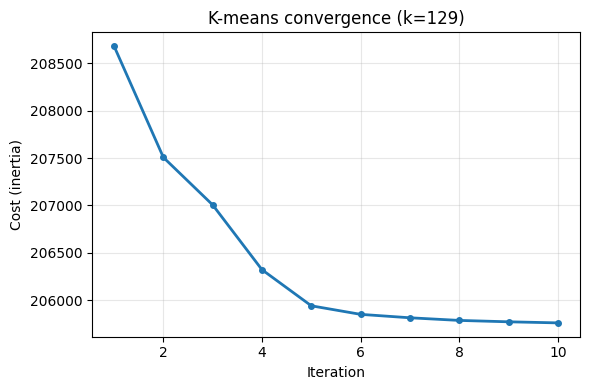

In [15]:
# if tracked cost:

import matplotlib.pyplot as plt

iterations = range(1, len(result["cost_history"]) + 1)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(iterations, result["cost_history"], marker="o", markersize=4, linewidth=2, color="tab:blue")
ax.set_xlabel("Iteration")
ax.set_ylabel("Cost (inertia)")
ax.set_title(f"K-means convergence (k={result['k']})")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

In [16]:
centroids_table = pd.DataFrame({
    "round": range(1, len(result["n_centroids_history"]) + 1),
    "n_centroids": result["n_centroids_history"],
})
centroids_table.style.set_caption(f"l = {result['l']}")

,round,n_centroids
0,1,437
1,2,885
2,3,1413
3,4,1922
4,5,2469


Compare with:
* Cost $19 \cdot 10^{10}$ ($k=500$, $l=0.5 k$, but $r=5$ instead - table 3.).
  HOWEVER, note that here we standardized data beforehand!
* Running time $69.0 \text{ min}$ for the same values (table 4)

## 6. Multi-combination benchmark

Testa più combinazioni di `(n_workers, partitions, l_over_k, r)` per diversi valori di `k`, e salva tutto in `./results`. 

**Nota:** il numero di worker effettivamente attivi nel cluster è quello impostato con `launch_cluster` in sezione 3 — la colonna `workers` qui sotto serve solo per etichettare/loggare i risultati, non riavvia il cluster.

### Varying number of workers

#### On 10% dataset

In [ ]:
# write as function? but this is clearer and not that long

In [10]:
# as best combination (for cost) in figure 5.1 in original paper:

R = 5 

l_over_k = 4

K_VALUES=[129]

MAX_ITER_FIT=10 # unimportant to get perfect convergence,
                # as we're investigating only ideal number of workers (wrt to computation time)

In [18]:
n_workers=[2,4,6,8]

avg_iters=3

In [19]:
shutdown_cluster(cluster,client)

Cluster e client chiusi.


In [20]:
frames = []
for n in n_workers:
    cluster, client = launch_cluster(n)
    X_bag_10_percent, _ = load_dataset(n_partitions=8*n,
                   client=client,
                   dataset_url=DATASET_URL_10PC,
                   raw_gz_path=RAW_GZ_PATH_10PC,
                   parquet_path=PARQUET_PATH_10PC,
                   parquet_path_workers=PARQUET_PATH_10PC,
                   col_names=COL_NAMES,
                   force_download=False)  # rebuild bag on new client - perhaps unnenecessary??
    
    df_n = run_benchmark(client, X_bag=X_bag_10_percent,
                         combinations=combinations_fn(n_workers=n,l_over_k=l_over_k,r=R),
                         # function assigning appropriate values (in particular n partitions = 8 * n workers)
                         k_values=K_VALUES, label=f"{n}_workers_10_percent", 
                         max_iter_fit=MAX_ITER_FIT, seed=SEED,
                         averaging_iterations=avg_iters)
    
    df_n["num_workers"] = n
    frames.append(df_n)
    shutdown_cluster(cluster, client)

df_all = pd.concat(frames, ignore_index=True)

Inizializzazione del cluster SSH con 2 worker...
Worker selezionati: ['10.67.22.254', '10.67.22.34']


2026-08-28 09:47:05,369 - distributed.deploy.ssh - INFO - 2026-08-28 09:47:05,368 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-08-28 09:47:05,396 - distributed.deploy.ssh - INFO - 2026-08-28 09:47:05,396 - distributed.scheduler - INFO - State start
2026-08-28 09:47:05,400 - distributed.deploy.ssh - INFO - 2026-08-28 09:47:05,400 - distributed.scheduler - INFO -   Scheduler at:   tcp://10.67.22.194:8786
2026-08-28 09:47:06,363 - distributed.deploy.ssh - INFO - 2026-08-28 09:47:06,357 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.254:33337'
2026-08-28 09:47:06,470 - distributed.deploy.ssh - INFO - 2026-08-28 09:47:06,469 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.34:43999'
2026-08-28 09:47:06,683 - distributed.deploy.ssh - INFO - 2026-08-28 09:47:06,677 - distributed.diskutils - INFO - Found stale lock file and directory '/t

Cluster avviato e connessione stabilita con successo!

Using cached dataset: /home/ubuntu/Project/libero_development/data/kddcup_data.gz
Converting .gz -> Parquet chunk sizes...
Parquet file created (compressed with snappy).
Number of partitions before preprocessing: 16
Constant columns: ['num_outbound_cmds', 'is_host_login']
Computing global mean and std (first pass over data)...
Distributed bag created with 8 partitions.
Number of samples: 494021
Testing: k=129, workers=2, partitions=16, l=516 (l/k=4), r=5
 Iterating 3 times.
Iteration 0
 -> Final cost: 202167.36 | Time: 22.09s
Iteration 1
 -> Final cost: 202186.84 | Time: 22.19s
Iteration 2
 -> Final cost: 202869.25 | Time: 20.32s

Risultati completi salvati in: /home/ubuntu/Project/libero_development/results/2_workers_10_percent20260828094726.csv
--- Benchmark Complete ---
{'k': 129, 'l': 516, 'r': 5, 'r_effective': 5, 'partitions': 16, 'initial_cost': 205813.90227221142, 'final_cost': 202167.35773680924, 'time': 22.093929290771484

2026-08-28 09:49:01,045 - distributed.deploy.ssh - INFO - 2026-08-28 09:49:01,044 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-08-28 09:49:01,074 - distributed.deploy.ssh - INFO - 2026-08-28 09:49:01,074 - distributed.scheduler - INFO - State start
2026-08-28 09:49:01,080 - distributed.deploy.ssh - INFO - 2026-08-28 09:49:01,079 - distributed.scheduler - INFO -   Scheduler at:   tcp://10.67.22.194:8786
2026-08-28 09:49:02,211 - distributed.deploy.ssh - INFO - 2026-08-28 09:49:02,205 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.254:42979'
2026-08-28 09:49:02,283 - distributed.deploy.ssh - INFO - 2026-08-28 09:49:02,280 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.145:40137'
2026-08-28 09:49:02,363 - distributed.deploy.ssh - INFO - 2026-08-28 09:49:02,362 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.12

Cluster avviato e connessione stabilita con successo!

Using cached dataset: /home/ubuntu/Project/libero_development/data/kddcup_data.gz
Converting .gz -> Parquet chunk sizes...
Parquet file created (compressed with snappy).
Number of partitions before preprocessing: 32
Constant columns: ['num_outbound_cmds', 'is_host_login']
Computing global mean and std (first pass over data)...
Distributed bag created with 16 partitions.
Number of samples: 494021
Testing: k=129, workers=4, partitions=32, l=516 (l/k=4), r=5
 Iterating 3 times.
Iteration 0
 -> Final cost: 202506.70 | Time: 18.85s
Iteration 1
 -> Final cost: 197852.42 | Time: 17.41s
Iteration 2
 -> Final cost: 203152.22 | Time: 17.93s

Risultati completi salvati in: /home/ubuntu/Project/libero_development/results/4_workers_10_percent20260828094916.csv
--- Benchmark Complete ---
{'k': 129, 'l': 516, 'r': 5, 'r_effective': 5, 'partitions': 32, 'initial_cost': 201964.36722157727, 'final_cost': 197852.42397073473, 'time': 17.40646672248840

2026-08-28 09:50:32,449 - distributed.deploy.ssh - INFO - 2026-08-28 09:50:32,448 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-08-28 09:50:32,475 - distributed.deploy.ssh - INFO - 2026-08-28 09:50:32,475 - distributed.scheduler - INFO - State start
2026-08-28 09:50:32,479 - distributed.deploy.ssh - INFO - 2026-08-28 09:50:32,478 - distributed.scheduler - INFO -   Scheduler at:   tcp://10.67.22.194:8786
2026-08-28 09:50:33,938 - distributed.deploy.ssh - INFO - 2026-08-28 09:50:33,935 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.145:45169'
2026-08-28 09:50:33,965 - distributed.deploy.ssh - INFO - 2026-08-28 09:50:33,967 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.18:38089'
2026-08-28 09:50:33,978 - distributed.deploy.ssh - INFO - 2026-08-28 09:50:33,972 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.254

Cluster avviato e connessione stabilita con successo!

Using cached dataset: /home/ubuntu/Project/libero_development/data/kddcup_data.gz
Converting .gz -> Parquet chunk sizes...
Parquet file created (compressed with snappy).
Number of partitions before preprocessing: 48
Constant columns: ['num_outbound_cmds', 'is_host_login']
Computing global mean and std (first pass over data)...
Distributed bag created with 24 partitions.
Number of samples: 494021
Testing: k=129, workers=6, partitions=48, l=516 (l/k=4), r=5
 Iterating 3 times.
Iteration 0
 -> Final cost: 201081.35 | Time: 15.67s
Iteration 1
 -> Final cost: 202548.97 | Time: 15.34s
Iteration 2
 -> Final cost: 201879.72 | Time: 16.72s

Risultati completi salvati in: /home/ubuntu/Project/libero_development/results/6_workers_10_percent20260828095047.csv
--- Benchmark Complete ---
{'k': 129, 'l': 516, 'r': 5, 'r_effective': 5, 'partitions': 48, 'initial_cost': 202860.46598011264, 'final_cost': 201081.3530842932, 'time': 15.674044847488403

2026-08-28 09:51:52,143 - distributed.deploy.ssh - INFO - 2026-08-28 09:51:52,142 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-08-28 09:51:52,198 - distributed.deploy.ssh - INFO - 2026-08-28 09:51:52,197 - distributed.scheduler - INFO - State start
2026-08-28 09:51:52,203 - distributed.deploy.ssh - INFO - 2026-08-28 09:51:52,202 - distributed.scheduler - INFO -   Scheduler at:   tcp://10.67.22.194:8786
2026-08-28 09:51:53,961 - distributed.deploy.ssh - INFO - 2026-08-28 09:51:53,956 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.254:39575'
2026-08-28 09:51:53,999 - distributed.deploy.ssh - INFO - 2026-08-28 09:51:53,998 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.121:45963'
2026-08-28 09:51:54,001 - distributed.deploy.ssh - INFO - 2026-08-28 09:51:54,003 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.18

Cluster avviato e connessione stabilita con successo!

Using cached dataset: /home/ubuntu/Project/libero_development/data/kddcup_data.gz
Converting .gz -> Parquet chunk sizes...
Parquet file created (compressed with snappy).
Number of partitions before preprocessing: 64
Constant columns: ['num_outbound_cmds', 'is_host_login']
Computing global mean and std (first pass over data)...
Distributed bag created with 32 partitions.
Number of samples: 494021
Testing: k=129, workers=8, partitions=64, l=516 (l/k=4), r=5
 Iterating 3 times.
Iteration 0
 -> Final cost: 199493.32 | Time: 16.85s
Iteration 1
 -> Final cost: 198606.40 | Time: 15.51s
Iteration 2
 -> Final cost: 203570.77 | Time: 15.63s

Risultati completi salvati in: /home/ubuntu/Project/libero_development/results/8_workers_10_percent20260828095206.csv
--- Benchmark Complete ---
{'k': 129, 'l': 516, 'r': 5, 'r_effective': 5, 'partitions': 64, 'initial_cost': 201728.93527900297, 'final_cost': 198606.3961635848, 'time': 15.511807441711426

In [6]:
import os

In [21]:
RESULTS_DIR = "/home/ubuntu/Project/libero_development/results"
FIGURES_DIR= "/home/ubuntu/Project/libero_development/figures"
os.makedirs(RESULTS_DIR, exist_ok=True)
csv_path = os.path.join(RESULTS_DIR, f"worker_sweep_{time.strftime('%Y%m%d%H%M%S')}_10pc.csv")
figure_path=os.path.join(FIGURES_DIR, f"worker_sweep_{time.strftime('%Y%m%d%H%M%S')}_10pc.png")
df_all.to_csv(csv_path, index=False)
print(f"Saved to: {csv_path}")

Saved to: /home/ubuntu/Project/libero_development/results/worker_sweep_20260828095433_10pc.csv


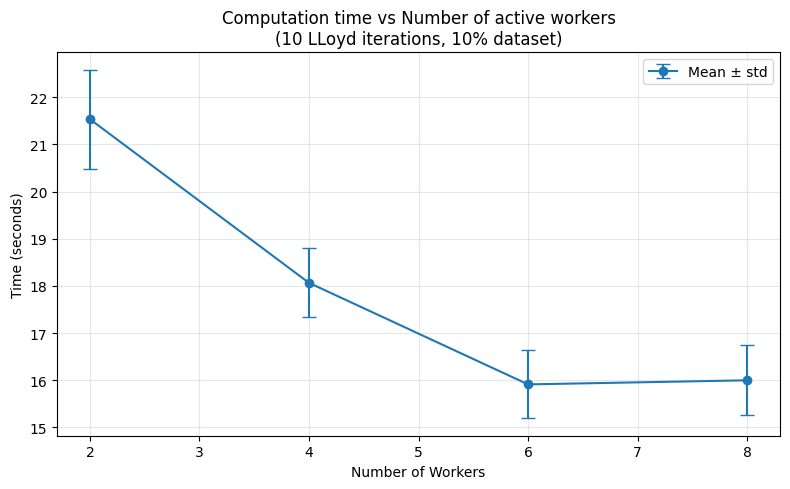

In [22]:
# Group by number of workers, compute mean and std of time
stats = df_all.groupby("num_workers")["time"].agg(["mean", "std"]).reset_index()

plt.figure(figsize=(8, 5))
plt.errorbar(
    stats["num_workers"], 
    stats["mean"], 
    yerr=stats["std"], 
    marker="o", 
    capsize=5,
    linestyle="-",
    label="Mean ± std"
)
plt.xlabel("Number of Workers")
plt.ylabel("Time (seconds)")
plt.title("Computation time vs Number of active workers\n(10 LLoyd iterations, 10% dataset)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(figure_path, dpi=150)
plt.show()

In [ ]:
# and, can check directly to see that similar final cost for any number of workers

#### On full dataset

In [17]:
import importlib
import src.kmeans_parallel
importlib.reload(src.kmeans_parallel)
from src.kmeans_parallel import kmeans_parallel

In [5]:
n_workers=[5,4,3,2]

avg_iters=1

In [9]:
# other params same as above

In [11]:
shutdown_cluster(cluster,client)

Cluster e client chiusi.


In [6]:
import dask

In [12]:
frames = []
for n in n_workers:
    #dask.config.set({"distributed.scheduler.work-stealing": True})
    cluster, client = launch_cluster(n)
    mt=client.run(lambda: __import__('ctypes').CDLL("libc.so.6").malloc_trim(0))
    print(mt)
    X_bag_full, _ = load_dataset(n_partitions=8*n,
                   client=client,
                   dataset_url=DATASET_URL_FULL,
                   raw_gz_path=RAW_GZ_PATH_FULL,
                   parquet_path=PARQUET_PATH_FULL,
                   parquet_path_workers=PARQUET_PATH_FULL,
                   col_names=COL_NAMES,
                   force_download=False)  # rebuild bag on new client
    
    df_n = run_benchmark(client, X_bag=X_bag_full,
                         combinations=combinations_fn(n_workers=n,l_over_k=l_over_k,r=R),
                         # function assigning appropriate values (in particular n partitions = 8 * n workers)
                         k_values=K_VALUES, label=f"{n}_workers_full", 
                         max_iter_fit=MAX_ITER_FIT, seed=SEED,
                         averaging_iterations=avg_iters)
    
    df_n["num_workers"] = n
    frames.append(df_n)
    shutdown_cluster(cluster, client)

df_all = pd.concat(frames, ignore_index=True)

Inizializzazione del cluster SSH con 5 worker...
Worker selezionati: ['10.67.22.254', '10.67.22.34', '10.67.22.145', '10.67.22.121', '10.67.22.192']


2026-08-28 14:49:44,900 - distributed.deploy.ssh - INFO - 2026-08-28 14:49:44,899 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-08-28 14:49:44,927 - distributed.deploy.ssh - INFO - 2026-08-28 14:49:44,927 - distributed.scheduler - INFO - State start
2026-08-28 14:49:44,931 - distributed.deploy.ssh - INFO - 2026-08-28 14:49:44,930 - distributed.scheduler - INFO -   Scheduler at:   tcp://10.67.22.194:8786
2026-08-28 14:49:46,354 - distributed.deploy.ssh - INFO - 2026-08-28 14:49:46,357 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.145:33363'
2026-08-28 14:49:46,499 - distributed.deploy.ssh - INFO - 2026-08-28 14:49:46,501 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.121:46475'
2026-08-28 14:49:46,509 - distributed.deploy.ssh - INFO - 2026-08-28 14:49:46,506 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.25

Cluster avviato e connessione stabilita con successo!

{'tcp://10.67.22.121:46265': 1, 'tcp://10.67.22.145:40475': 1, 'tcp://10.67.22.192:36851': 1, 'tcp://10.67.22.254:46725': 1, 'tcp://10.67.22.34:40369': 1}
Using cached dataset: /home/ubuntu/backup/libero_development/data/kddcup_data_full.gz
Converting .gz -> Parquet chunk sizes...
Parquet file created (compressed with snappy).
Number of partitions before preprocessing: 40
Constant columns: ['num_outbound_cmds']
Computing global mean and std (first pass over data)...
Distributed bag created with 20 partitions.
Number of samples: 4898431
Testing: k=129, workers=5, partitions=40, l=516 (l/k=4), r=5
 Iterating 1 times.
Iteration 0
 -> Final cost: 2167392.53 | Time: 312.77s | Time for LLoyd iterations only: 40.86s

Risultati completi salvati in: /home/ubuntu/Project/libero_development/results/5_workers_full20260828145105.csv
--- Benchmark Complete ---
{'k': 129, 'l': 516, 'r': 5, 'r_effective': 5, 'partitions': 40, 'initial_cost': 21909

2026-08-28 14:56:56,379 - distributed.deploy.ssh - INFO - 2026-08-28 14:56:56,378 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-08-28 14:56:56,407 - distributed.deploy.ssh - INFO - 2026-08-28 14:56:56,406 - distributed.scheduler - INFO - State start
2026-08-28 14:56:56,411 - distributed.deploy.ssh - INFO - 2026-08-28 14:56:56,410 - distributed.scheduler - INFO -   Scheduler at:   tcp://10.67.22.194:8786
2026-08-28 14:56:57,956 - distributed.deploy.ssh - INFO - 2026-08-28 14:56:57,958 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.121:41175'
2026-08-28 14:56:58,122 - distributed.deploy.ssh - INFO - 2026-08-28 14:56:58,120 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.254:43139'
2026-08-28 14:56:58,156 - distributed.deploy.ssh - INFO - 2026-08-28 14:56:58,159 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.14

Cluster avviato e connessione stabilita con successo!

{'tcp://10.67.22.121:38411': 1, 'tcp://10.67.22.145:41523': 1, 'tcp://10.67.22.254:44713': 1, 'tcp://10.67.22.34:45349': 1}
Using cached dataset: /home/ubuntu/backup/libero_development/data/kddcup_data_full.gz
Converting .gz -> Parquet chunk sizes...
Parquet file created (compressed with snappy).
Number of partitions before preprocessing: 32
Constant columns: ['num_outbound_cmds']
Computing global mean and std (first pass over data)...
Distributed bag created with 16 partitions.
Number of samples: 4898431
Testing: k=129, workers=4, partitions=32, l=516 (l/k=4), r=5
 Iterating 1 times.
Iteration 0


2026-08-28 15:01:00,634 - distributed.client - WARNING - Couldn't gather 3 keys, rescheduling ('_sample_round-a067e69a-300a-4a89-90bd-33f8c2c5fad5', '_sample_round-861a509a-f52d-4eb7-a058-2737e035b52c', '_sample_round-48d979fe-1ea5-4c33-a038-f91dfdbd81c2')


KilledWorker: Attempted to run task '_update_state-b3e40c93-48f7-4f2a-98ba-884032876b0a' on 4 different workers, but all those workers died while running it. The last worker that attempt to run the task was tcp://10.67.22.34:35203. Inspecting worker logs is often a good next step to diagnose what went wrong. For more information see https://distributed.dask.org/en/stable/killed.html.

In [13]:
# after the crash, check what happened right before death
client.get_worker_logs()

{'tcp://10.67.22.121:41003': (('INFO',
   '2026-08-28 15:04:21,992 - distributed.worker - INFO - -------------------------------------------------'),
  ('INFO',
   '2026-08-28 15:04:21,992 - distributed.worker - INFO -         Registered to:    tcp://10.67.22.194:8786'),
  ('INFO',
   '2026-08-28 15:04:21,992 - distributed.worker - INFO - Starting Worker plugin shuffle'),
  ('INFO',
   '2026-08-28 15:04:21,967 - distributed.worker - INFO - -------------------------------------------------'),
  ('INFO',
   '2026-08-28 15:04:21,967 - distributed.worker - INFO -       Local Directory: /tmp/dask-scratch-space/worker-taytj_j6'),
  ('INFO',
   '2026-08-28 15:04:21,967 - distributed.worker - INFO -                Memory:                   7.75 GiB'),
  ('INFO',
   '2026-08-28 15:04:21,967 - distributed.worker - INFO -               Threads:                          8'),
  ('INFO',
   '2026-08-28 15:04:21,967 - distributed.worker - INFO - -------------------------------------------------'),
  

In [17]:
client.upload_file('/home/ubuntu/Project/libero_development/src/kmeans_parallel.py')

{'tcp://10.67.22.121:41003': {'status': 'OK'},
 'tcp://10.67.22.145:32959': {'status': 'OK'},
 'tcp://10.67.22.254:40477': {'status': 'OK'},
 'tcp://10.67.22.34:39531': {'status': 'OK'}}

In [18]:
def check_version():
    import src.kmeans_parallel
    import inspect
    return inspect.getsource(src.kmeans_parallel._update_state)

print(client.run(check_version))

{'tcp://10.67.22.121:41003': 'def _update_state(M, state, new_centroids, start_idx):\n    """Aggiorna lo stato (d^2 min, indice centroide) dopo aver aggiunto i\n    candidati ``new_centroids`` (t, d) che partono dall\'indice start_idx.\n\n    Ritorna (stato aggiornato, somma parziale delle d^2 minime): il costo\n    del round e\' fuso nell\'aggiornamento, cosicche\' attraverso il confine\n    client/cluster passa solo lo scalare e non la matrice di stato.\n    """\n    if M.shape[0] == 0 or new_centroids.shape[0] == 0:\n        return state, float(state[:, 0].sum())\n    d2_new = _pairwise_d2(M, new_centroids)\n    min_new_idx = d2_new.argmin(axis=1)\n    min_new_dist = d2_new[np.arange(M.shape[0]), min_new_idx]\n    closer = min_new_dist < state[:, 0]\n    out = state.copy()\n    out[closer, 0] = min_new_dist[closer]\n    out[closer, 1] = (min_new_idx[closer] + start_idx).astype(state[:, 1].dtype)\n    return out, float(out[:, 0].sum())\n', 'tcp://10.67.22.145:32959': 'def _update_sta

In [ ]:
# save results
csv_path = os.path.join(RESULTS_DIR, f"worker_sweep_{time.strftime('%Y%m%d%H%M%S')}_full.csv")
figure_path=os.path.join(FIGURES_DIR, f"worker_sweep_{time.strftime('%Y%m%d%H%M%S')}_full.png")
df_all.to_csv(csv_path, index=False)
print(f"Saved to: {csv_path}")

In [ ]:
# plot result

# Group by number of workers, compute mean and std of time
stats = df_all.groupby("num_workers")["time"].agg(["mean", "std"]).reset_index()

plt.figure(figsize=(8, 5))
plt.errorbar(
    stats["num_workers"], 
    stats["mean"], 
    yerr=stats["std"], 
    marker="o", 
    capsize=5,
    linestyle="-",
    label="Mean ± std"
)
plt.xlabel("Number of Workers")
plt.ylabel("Time (seconds)")
plt.title("Computation time vs Number of active workers\n(10 LLoyd iterations, full dataset)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(figure_path, dpi=150)
plt.show()

### Varying number of partitions

#### On 10% dataset

In [ ]:
dataset_bag= X_bag_10_percent
avg_iters=10

In [ ]:
# other params same as above

In [ ]:
combos = [                      
    (N_WORKERS, 32, l_over_k, R),   # under-partitioned
    (N_WORKERS, 64, l_over_k, R),   # balanced (1 part/thread)
    #(N_WORKERS, 65, l_over_k, R),   # imbalanced
    (N_WORKERS, 128, l_over_k, R),  # over-partitioned
]

In [ ]:
df = run_benchmark(client, X_bag=dataset_bag, combinations=combos,
                   k_values=K_VALUES, label="num_partitions_10_percent",
                   max_iter_fit=MAX_ITER_FIT, seed=SEED, averaging_iterations=avg_iters)

In [ ]:
df

#### On full dataset

In [ ]:
# IMPORTANT NOTE: for sure comparison, at this point, we shut down and recreate cluster:

In [ ]:
shutdown_cluster(cluster,client)

In [ ]:
cluster, client= launch_cluster(N_WORKERS)

In [ ]:
# as best combination (for cost) in figure 5.1 in original paper:

dataset_bag= X_bag_full
avg_iters=3 # for faster results (small stdev anyways)

In [ ]:
# other params same as above

In [ ]:
df = run_benchmark(client, X_bag=dataset_bag, combinations=combos,
                   k_values=K_VALUES, label="num_partitions_full",
                   max_iter_fit=MAX_ITER_FIT, seed=SEED, averaging_iterations=avg_iters)

### Varying l_over_k 

#### On full dataset - (Tables 3 and 4 in original paper)

In [ ]:
dataset_bag= X_bag_full

R=5

num_threads= 64 # as found in previous code # NUM_PARTITIONS*2

K_VALUES=[500,1000]

MAX_ITER_FIT=100 # for best convergence (conv criterion??)

avg_iters=10

In [ ]:
combos = [
    (N_WORKERS, num_threads, 0.5, R)
    (N_WORKERS, num_threads, 1, R),  #FATTO
    (N_WORKERS, num_threads, 2, R),
    (N_WORKERS, num_threads, 10, R),
]

In [ ]:
df_results = run_benchmark(
    client, X_bag=dataset_bag,
    combinations=combos,
    k_values=K_VALUES,
    label="l_over_k_full",
    max_iter_fit=MAX_ITER_FIT,
    seed=SEED,
    averaging_iterations = avg_iters
)

In [ ]:
df_results

#### 6.1 Visualization of results

Per vedere i risultati ottenuti precedentemente

In [ ]:
from src.benchmark_analysis import BenchmarkAnalyzer

analyzer = BenchmarkAnalyzer(
    data_path="/home/ubuntu/Project/libero_development/notebooks/results/kddcup99_benchmark20260825193532.csv",
    output_dir="figures",
    facet_cols=["k"],              # una figura per ogni valore (combinazione) di queste colonne
    x_col="partitions",               # variabile sull'asse x
    metrics=["time"],       # colonne di cui calcolare mean/std e plottare
)
grouped = analyzer.compute_grouped_stats(groupby_cols=["k", "partitions"])
analyzer.print_summary(grouped)
analyzer.plot_all(grouped)

#### On 10% dataset - (Figure 5.1 in original paper)

## 7. Comparison to standard k-means algorithm

## Cluster shutdown

Da eseguire a fine lavoro, o prima di rilanciare `launch_cluster` con un `N_WORKERS` diverso.

In [ ]:
shutdown_cluster(cluster, client)